In [1]:
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.datasets as datasets
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from torchaudio.datasets import LIBRISPEECH
from torchaudio.models import Conformer
from visualisation import *
from wav2vec import Wav2Vec

(tensor([[0.0029, 0.0028, 0.0030,  ..., 0.0002, 0.0005, 0.0005]]), 16000, 'WATCH THE SAVAGES OUTSIDE SAID ROBERT', 2803, 154328, 21)
torch.Size([1, 48800])


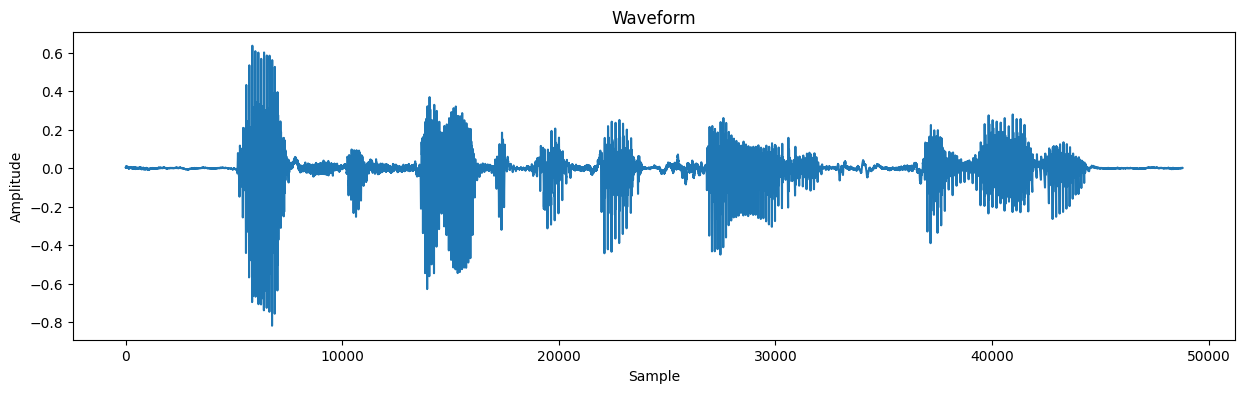

In [32]:
scraper = datasets.LIBRISPEECH("data", url="dev-clean",)
sample = scraper.__getitem__(1000)
print(sample)
waveform, sample_rate = sample[0], sample[1]
print(waveform.shape)
# аудиосигнал
plt.figure(figsize=(15, 4))
plt.plot(waveform.t().numpy())
plt.title('Waveform')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.show()

torch.Size([1, 64, 245]) torch.Size([1, 48800])


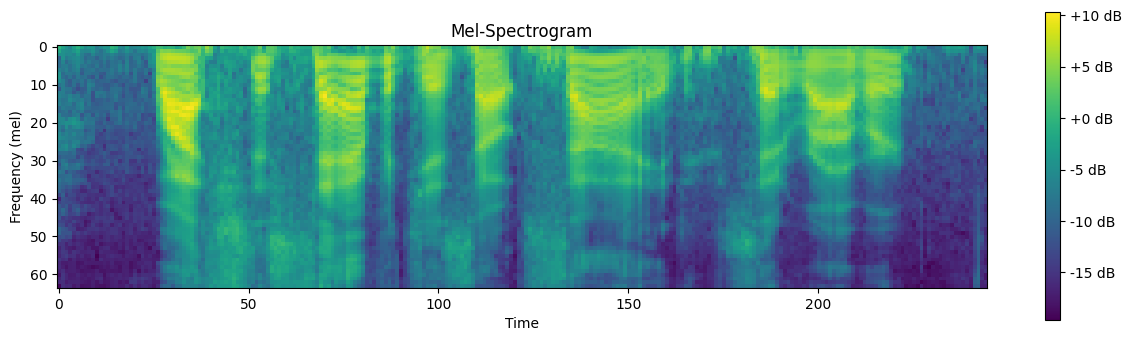

In [3]:
# спектрограмма
spec_transform = T.MelSpectrogram(n_mels=64,
    win_length=int(16000 * 0.025),
    hop_length=int(16000 * 0.025)//2,
    n_fft=1024)
mel_spec = spec_transform(waveform)
plt.figure(figsize=(15, 4))
print(mel_spec.shape, waveform.shape)
plt.imshow(mel_spec.log2()[0, :, :].numpy(), cmap='viridis')
plt.title('Mel-Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency (mel)')
plt.colorbar(format='%+2.0f dB')
plt.show()

torch.Size([201, 245])


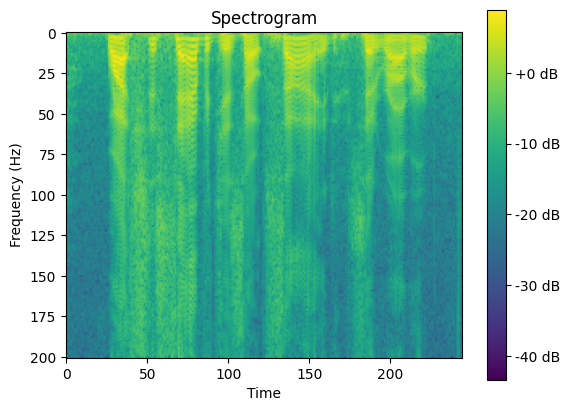

In [4]:
spec_transform = T.Spectrogram()
spec = spec_transform(waveform)
print(spec[0, :, :].shape)
plt.imshow(spec.log2()[0, :, :].numpy(), cmap='viridis')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.colorbar(format='%+2.0f dB')
plt.show()

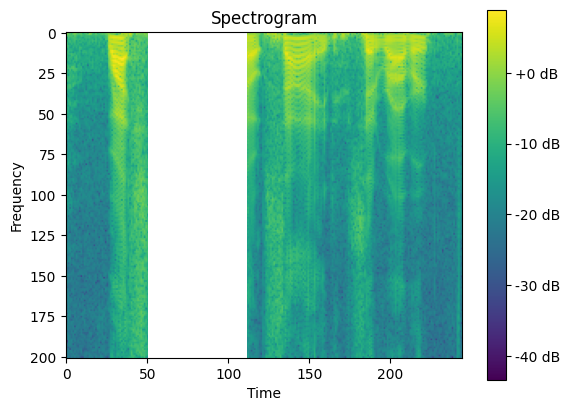

In [5]:
torch.random.manual_seed(1)

time_masking = T.TimeMasking(time_mask_param=80)
freq_masking = T.FrequencyMasking(freq_mask_param=80)

time_masked = time_masking(spec)
freq_masked = freq_masking(spec)

plt.imshow(time_masked.log2()[0, :, :].numpy(), cmap='viridis')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar(format='%+2.0f dB')
plt.show()

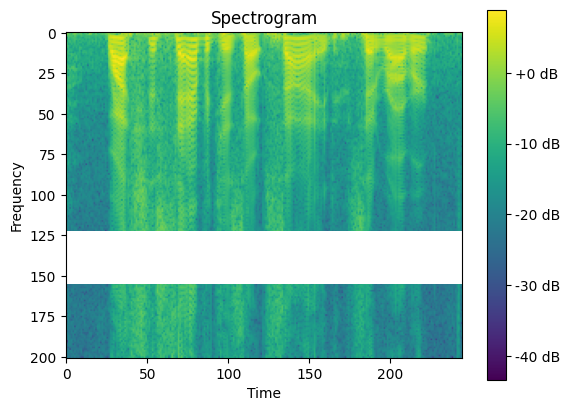

In [6]:
plt.imshow(freq_masked.log2()[0, :, :].numpy(), cmap='viridis')
plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.colorbar(format='%+2.0f dB')
plt.show()

In [7]:
def get_spec(n: int, mel=False, dataset_api=LIBRISPEECH("data", url="dev-clean")):
    sample = dataset_api.__getitem__(n)

    waveform, sample_rate = sample[0], sample[1]
    if mel:
        spec_transform = T.MelSpectrogram(n_mels=128,
        win_length=1024,
        hop_length=512,
        n_fft=1024)
    else:
        spec_transform = T.Spectrogram()
    spec = spec_transform(waveform)
    return spec[0]

spectrograms = [get_spec(0), get_spec(1), get_spec(2)]

In [8]:
print(spectrograms[0].shape)
[print(spec.shape[1]) for spec in spectrograms]
lengths = torch.tensor([spec.shape[1] for spec in spectrograms])
max_length = lengths.max().item()
print(max_length)

torch.Size([201, 469])
469
386
999
999


In [9]:
print(spectrograms[0].shape)
from torch.nn.utils.rnn import pad_sequence

padded_spectrograms = pad_sequence(
    [spec.T for spec in spectrograms],  # Транспонируем: (частоты, время) -> (время, частоты)
    batch_first=True,                   # Сохраняем batch_first формат
    padding_value=0                     # Значение для паддинга
)

# Возвращаем обратно формы после паддинга
padded_spectrograms = padded_spectrograms.transpose(1, 2)  # (время, частоты) -> (частоты, время)

print(padded_spectrograms.shape)

torch.Size([201, 469])
torch.Size([3, 201, 999])


In [10]:
spectrograms = [get_spec(0, mel=True), get_spec(1, mel=True), get_spec(2, mel=True)]
print(spectrograms[0].shape,
      spectrograms[1].shape,
      spectrograms[2].shape,)
lengths = torch.tensor([spectrograms[0].shape[1],
           spectrograms[1].shape[1],
           spectrograms[2].shape[1]], dtype=torch.int16)
print(lengths)
padded_spectrograms = pad_sequence(
    [spec.T for spec in spectrograms],  # Транспонируем: (частоты, время) -> (время, частоты)
    batch_first=True,                   # Сохраняем batch_first формат
    padding_value=0                     # Значение для паддинга
)

print(padded_spectrograms.shape)

input = torch.rand((3, int(lengths.max()), 128))
print(input.shape)
print()
print(input)

torch.Size([128, 183]) torch.Size([128, 151]) torch.Size([128, 391])
tensor([183, 151, 391], dtype=torch.int16)
torch.Size([3, 391, 128])
torch.Size([3, 391, 128])

tensor([[[0.0293, 0.7999, 0.3971,  ..., 0.9642, 0.1895, 0.6085],
         [0.9314, 0.8313, 0.8116,  ..., 0.8074, 0.4710, 0.4384],
         [0.9544, 0.9371, 0.2165,  ..., 0.8206, 0.6776, 0.6237],
         ...,
         [0.6508, 0.0036, 0.7097,  ..., 0.6335, 0.1246, 0.4427],
         [0.4380, 0.7390, 0.6422,  ..., 0.5149, 0.9533, 0.3389],
         [0.2103, 0.0243, 0.8999,  ..., 0.6227, 0.4643, 0.8213]],

        [[0.0671, 0.3827, 0.0189,  ..., 0.9100, 0.3681, 0.5268],
         [0.1061, 0.2887, 0.2875,  ..., 0.7673, 0.5365, 0.9787],
         [0.2602, 0.7342, 0.5583,  ..., 0.4259, 0.6909, 0.2079],
         ...,
         [0.7555, 0.0601, 0.1320,  ..., 0.4809, 0.2754, 0.8558],
         [0.8437, 0.6903, 0.2402,  ..., 0.3717, 0.8865, 0.8630],
         [0.0539, 0.1770, 0.7089,  ..., 0.8551, 0.0213, 0.1454]],

        [[0.7883, 0.777

In [11]:
sample = scraper.__getitem__(1)
print(sample[2])
print(type(sample[2]))

NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER
<class 'str'>


torch.Size([128, 151])
torch.Size([1, 151, 128])
torch.Size([1, 151, 32])
torch.Size([1, 151, 64])


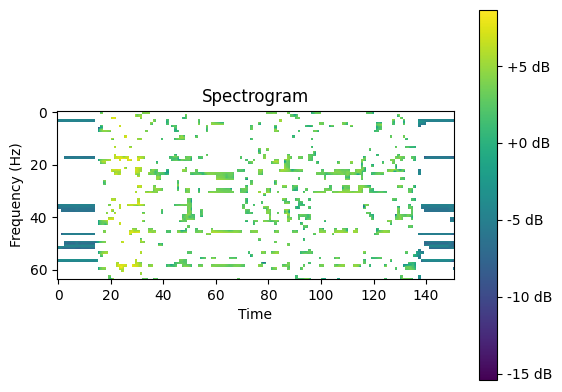

In [21]:
mel = get_spec(1, mel=True)
print(mel.shape)
#plot_spectrogram(mel)

mel = mel.reshape(1, mel.shape[0], mel.shape[1]).transpose(2, 1)
print(mel.shape)

linear = nn.Linear(in_features=128, out_features=32)
mel = linear(mel)
print(mel.shape)

conv = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
mel = conv(mel.transpose(1, 2)).transpose(1, 2)
print(mel.shape)

mel = mel.transpose(1, 2)
# timeFrq = T.TimeMasking(time_mask_param=20)
# mel = timeFrq(mel)
# print(mel.shape)
spec = mel
spec = spec.detach()
plot_spectrogram(spec[0])
mel = mel.transpose(1, 2)

In [13]:
conf = Conformer(input_dim=64,
                 num_heads=4,
                 ffn_dim=128,
                 num_layers=2,
                 depthwise_conv_kernel_size=3,
                 dropout=0.2)
length = torch.tensor([mel.shape[1]])
print(mel.shape)
y, lengths = conf(mel, length)
print(y.shape, lengths)

torch.Size([1, 151, 64])
torch.Size([1, 151, 64]) tensor([151])


In [15]:
wav2vec = Wav2Vec(64, 128, 128, 5, 4, 2, 0.2)
y, x = wav2vec(mel, length)
print(y.shape, x.shape)

TypeError: linear(): argument 'input' (position 1) must be Tensor, not NoneType

In [31]:
#plot_spectrogram(mel[0].detach())
print(mel.shape)
def mask_rows(tensor, mask_ratio=0.5):
    """
    Замаскировать часть строк в батче.
    :param tensor: входной тензор с размерностью (bs, T, a)
    :param mask_ratio: доля строк, которые нужно замаскировать
    :return: замаскированный тензор, список с индексами замаскированных строк
    """
    bs, T, a = tensor.size()
    
    # Создание маски для строк
    mask = torch.ones(T, dtype=torch.bool)
    
    # Определяем количество строк для маскирования
    num_masked_rows = int(mask_ratio * T)
    
    # Выбираем случайные индексы строк для маскирования
    masked_indices = torch.randperm(T)[:num_masked_rows]
    
    # Обновляем маску на основе выбранных индексов
    mask[masked_indices] = 0
    
    # Применяем маску к тензору: строки, соответствующие 0 в маске, будут обнулены
    masked_tensor = tensor.clone()
    masked_tensor[:, ~mask, :] = 0

    return masked_tensor, masked_indices

# Пример использования
bs, T, a = 5, 300, 256
torch.manual_seed(0)  # Для повторяемости результатов
input_tensor = torch.randn(bs, T, a)
masked_tensor, masked_indices = mask_rows(input_tensor, mask_ratio=0.2)

print("Индексы замаскированных строк:")
print(masked_indices)
print("\nЗамаскированный тензор:")
print(masked_tensor[:, masked_indices, :].shape)

torch.Size([1, 151, 64])
Индексы замаскированных строк:
tensor([151, 263, 256,  87,  34, 131, 297,  19, 221, 144,  22,  74,  58, 215,
        119, 250,  55,  69, 247,  97, 268,  37,  76,  71,  47, 254, 252,  31,
        210,   9, 284, 201, 184,  49,  95, 103, 204,  10, 141, 276, 289,  66,
        167,   6, 231,  54, 228, 218, 102, 211, 238,  48, 163, 237, 226, 145,
        219, 124, 113, 148])

Замаскированный тензор:
torch.Size([5, 60, 256])
